In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from datetime import datetime
from scipy.integrate import cumulative_trapezoid
from scipy.signal import butter, filtfilt, detrend

In [ ]:
TEST = "sit"
PLOT_VEL = True

opti_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/optitrack/410{TEST}_opti.csv"

with open(opti_filename, 'r') as f:
    metadata = next(f)
    metadata_list = metadata.split(',')
    metadata_dict = {metadata_list[i]: metadata_list[i+1] for i in range(0, len(metadata_list), 2)}

    df_opti = pd.read_csv(f, skiprows=4, header=[0, 1])
    

start_time = datetime.strptime(metadata_dict['Capture Start Time'], "%Y-%m-%d %I.%M.%S.%f %p")

df_opti = df_opti.iloc[:, :8]
df_opti.columns = ["_".join([i.lower() for i in col if "Unnamed" not in i]) for col in df_opti.columns.values]
df_opti['timestampEpoch'] = df_opti['time (seconds)'] + start_time.timestamp()
df_opti['timestampEpoch'] *= 1000
# df_opti

In [ ]:
app_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/airpods/410{TEST}.csv"
df_app = pd.read_csv(app_filename)
df_app = df_app.loc[df_app["source"] == "airpods"]
df_app = df_app.iloc[1:]
# df_app

In [ ]:
time_opti = df_opti["timestampEpoch"].values
time_app = df_app["timestampEpoch"].values

# Mask to get overlapping time only
time_start = max(time_opti[0], time_app[0])
time_end = min(time_opti[-1], time_app[-1])
mask_opti = (time_opti >= time_start) & (time_opti <= time_end)
mask_app = (time_app >= time_start) & (time_app <= time_end)

time_opti = time_opti[mask_opti] / 1000 - 0.8 # convert to seconds
df_opti = df_opti[mask_opti]
time_app = time_app[mask_app] / 1000 # convert to seconds
df_app = df_app[mask_app]

def lowpass_filter(signal, time, cutoff, order=4):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist

    b, a = butter(order, normalized_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

def highpass_filter(signal, time, cutoff, order=2):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff / nyquist, btype='high', analog=False)
    return filtfilt(b, a, signal)
    
lp_cutoff_opti = 10
lp_cutoff_app = 10
hp_cutoff = 0.5

px_opti = df_opti["position_x"].values / 1000
py_opti = df_opti["position_y"].values / 1000
pz_opti = df_opti["position_z"].values / 1000
px_opti_f = lowpass_filter(px_opti, time_opti, lp_cutoff, 4)
py_opti_f = lowpass_filter(py_opti, time_opti, lp_cutoff, 4)
pz_opti_f = lowpass_filter(pz_opti, time_opti, lp_cutoff, 4)

vx_opti = np.gradient(px_opti, time_opti)
vy_opti = np.gradient(py_opti, time_opti)
vz_opti = np.gradient(pz_opti, time_opti)
vx_opti_f = np.gradient(px_opti_f, time_opti)
vy_opti_f = np.gradient(py_opti_f, time_opti)
vz_opti_f = np.gradient(pz_opti_f, time_opti)

ax_opti = np.gradient(vx_opti, time_opti)
ay_opti = np.gradient(vy_opti, time_opti)
az_opti = np.gradient(vz_opti, time_opti)

# convert Gs to m/s^2
ax_app = df_app["accel_x"].values * -9.81
ay_app = df_app["accel_y"].values * -9.81
az_app = df_app["accel_z"].values * -9.81
ax_app_f = detrend(ax_app, type='linear')
ay_app_f = detrend(ay_app, type='linear')
az_app_f = detrend(az_app, type='linear')
ax_app_f = lowpass_filter(ax_app_f, time_app, lp_cutoff, 2)
ay_app_f = lowpass_filter(ay_app_f, time_app, lp_cutoff, 2)
az_app_f = lowpass_filter(az_app_f, time_app, lp_cutoff, 2)
ax_app_f = highpass_filter(ax_app_f, time_app, hp_cutoff, 2)
ay_app_f = highpass_filter(ay_app_f, time_app, hp_cutoff, 2)
az_app_f = highpass_filter(az_app_f, time_app, hp_cutoff, 2)

vx_app = cumulative_trapezoid(ax_app, time_app, initial=0)
vy_app = cumulative_trapezoid(ay_app, time_app, initial=0)
vz_app = cumulative_trapezoid(az_app, time_app, initial=0)

vx_app_f = cumulative_trapezoid(ax_app_f, time_app, initial=0)
vy_app_f = cumulative_trapezoid(ay_app_f, time_app, initial=0)
vz_app_f = cumulative_trapezoid(az_app_f, time_app, initial=0)

fig, axes = plt.subplots(3, 1, figsize=(30, 30), sharex=True)

if PLOT_VEL: 
    # axes[0].plot(time_opti, vx_opti, label="X Velocity (optitrack)")
    axes[0].plot(time_opti, vx_opti_f, label="X Velocity F (optitrack)")
    # axes[0].plot(time_app, vx_app, linestyle="--", label="X Velocity (airpods)")
    axes[0].plot(time_app, vx_app_f, linestyle="--", label="X Velocity F (airpods)")
    axes[0].set_ylabel("X Velocity")
    axes[0].legend()
    axes[0].grid(True)
    
    # axes[1].plot(time_opti, vy_opti, label="Y Velocity (optitrack)")
    axes[1].plot(time_opti, vy_opti_f, label="Y Velocity F (optitrack)")
    # axes[1].plot(time_app, vy_app, linestyle="--", label="Y Velocity (airpods)")
    axes[1].plot(time_app, vy_app_f, linestyle="--", label="Y Velocity F (airpods)")
    axes[1].set_ylabel("Y Velocity")
    axes[1].legend()
    axes[1].grid(True)
    
    # axes[2].plot(time_opti, vz_opti, label="Z Velocity (optitrack)")
    axes[2].plot(time_opti, vz_opti_f, label="Z Velocity F (optitrack)")
    # axes[2].plot(time_app, vz_app, linestyle="--", label="Z Velocity (airpods)")
    axes[2].plot(time_app, vz_app_f, linestyle="--", label="Z Velocity F (airpods)")
    axes[2].set_ylabel("Z Velocity")
    axes[2].set_xlabel("Timestamp")
    axes[2].legend()
    axes[2].grid(True)
else: 
    # axes[0].plot(time_opti, ax_opti, label="X Acceleration (optitrack)")
    # axes[0].plot(time_app, ax_app, linestyle="--", label="X Acceleration (airpods)")
    # axes[0].plot(time_app, ax_app_f, linestyle="--", label="X Acceleration F (airpods)")
    axes[0].set_ylabel("X Acceleration")
    axes[0].legend()
    axes[0].grid(True)
    
    # axes[1].plot(time_opti, ay_opti, label="Y Acceleration (optitrack)")
    # axes[1].plot(time_app, ay_app, linestyle="--", label="Y Acceleration (airpods)")
    # axes[1].plot(time_app, ay_app_f, linestyle="--", label="Y Acceleration F (airpods)")
    axes[1].set_ylabel("Y Acceleration")
    axes[1].legend()
    axes[1].grid(True)
    
    # axes[2].plot(time_opti, az_opti, label="Z Acceleration (optitrack)")
    # axes[2].plot(time_app, az_app, linestyle="--", label="Z Acceleration (airpods)")
    # axes[2].plot(time_app, az_app_f, linestyle="--", label="Z Acceleration F (airpods)")
    axes[2].set_ylabel("Z Acceleration")
    axes[2].set_xlabel("Timestamp")
    axes[2].legend()
    axes[2].grid(True)

plt.suptitle("Velocity vs Time")
plt.show()


App RMSV:  0.05142948688792736


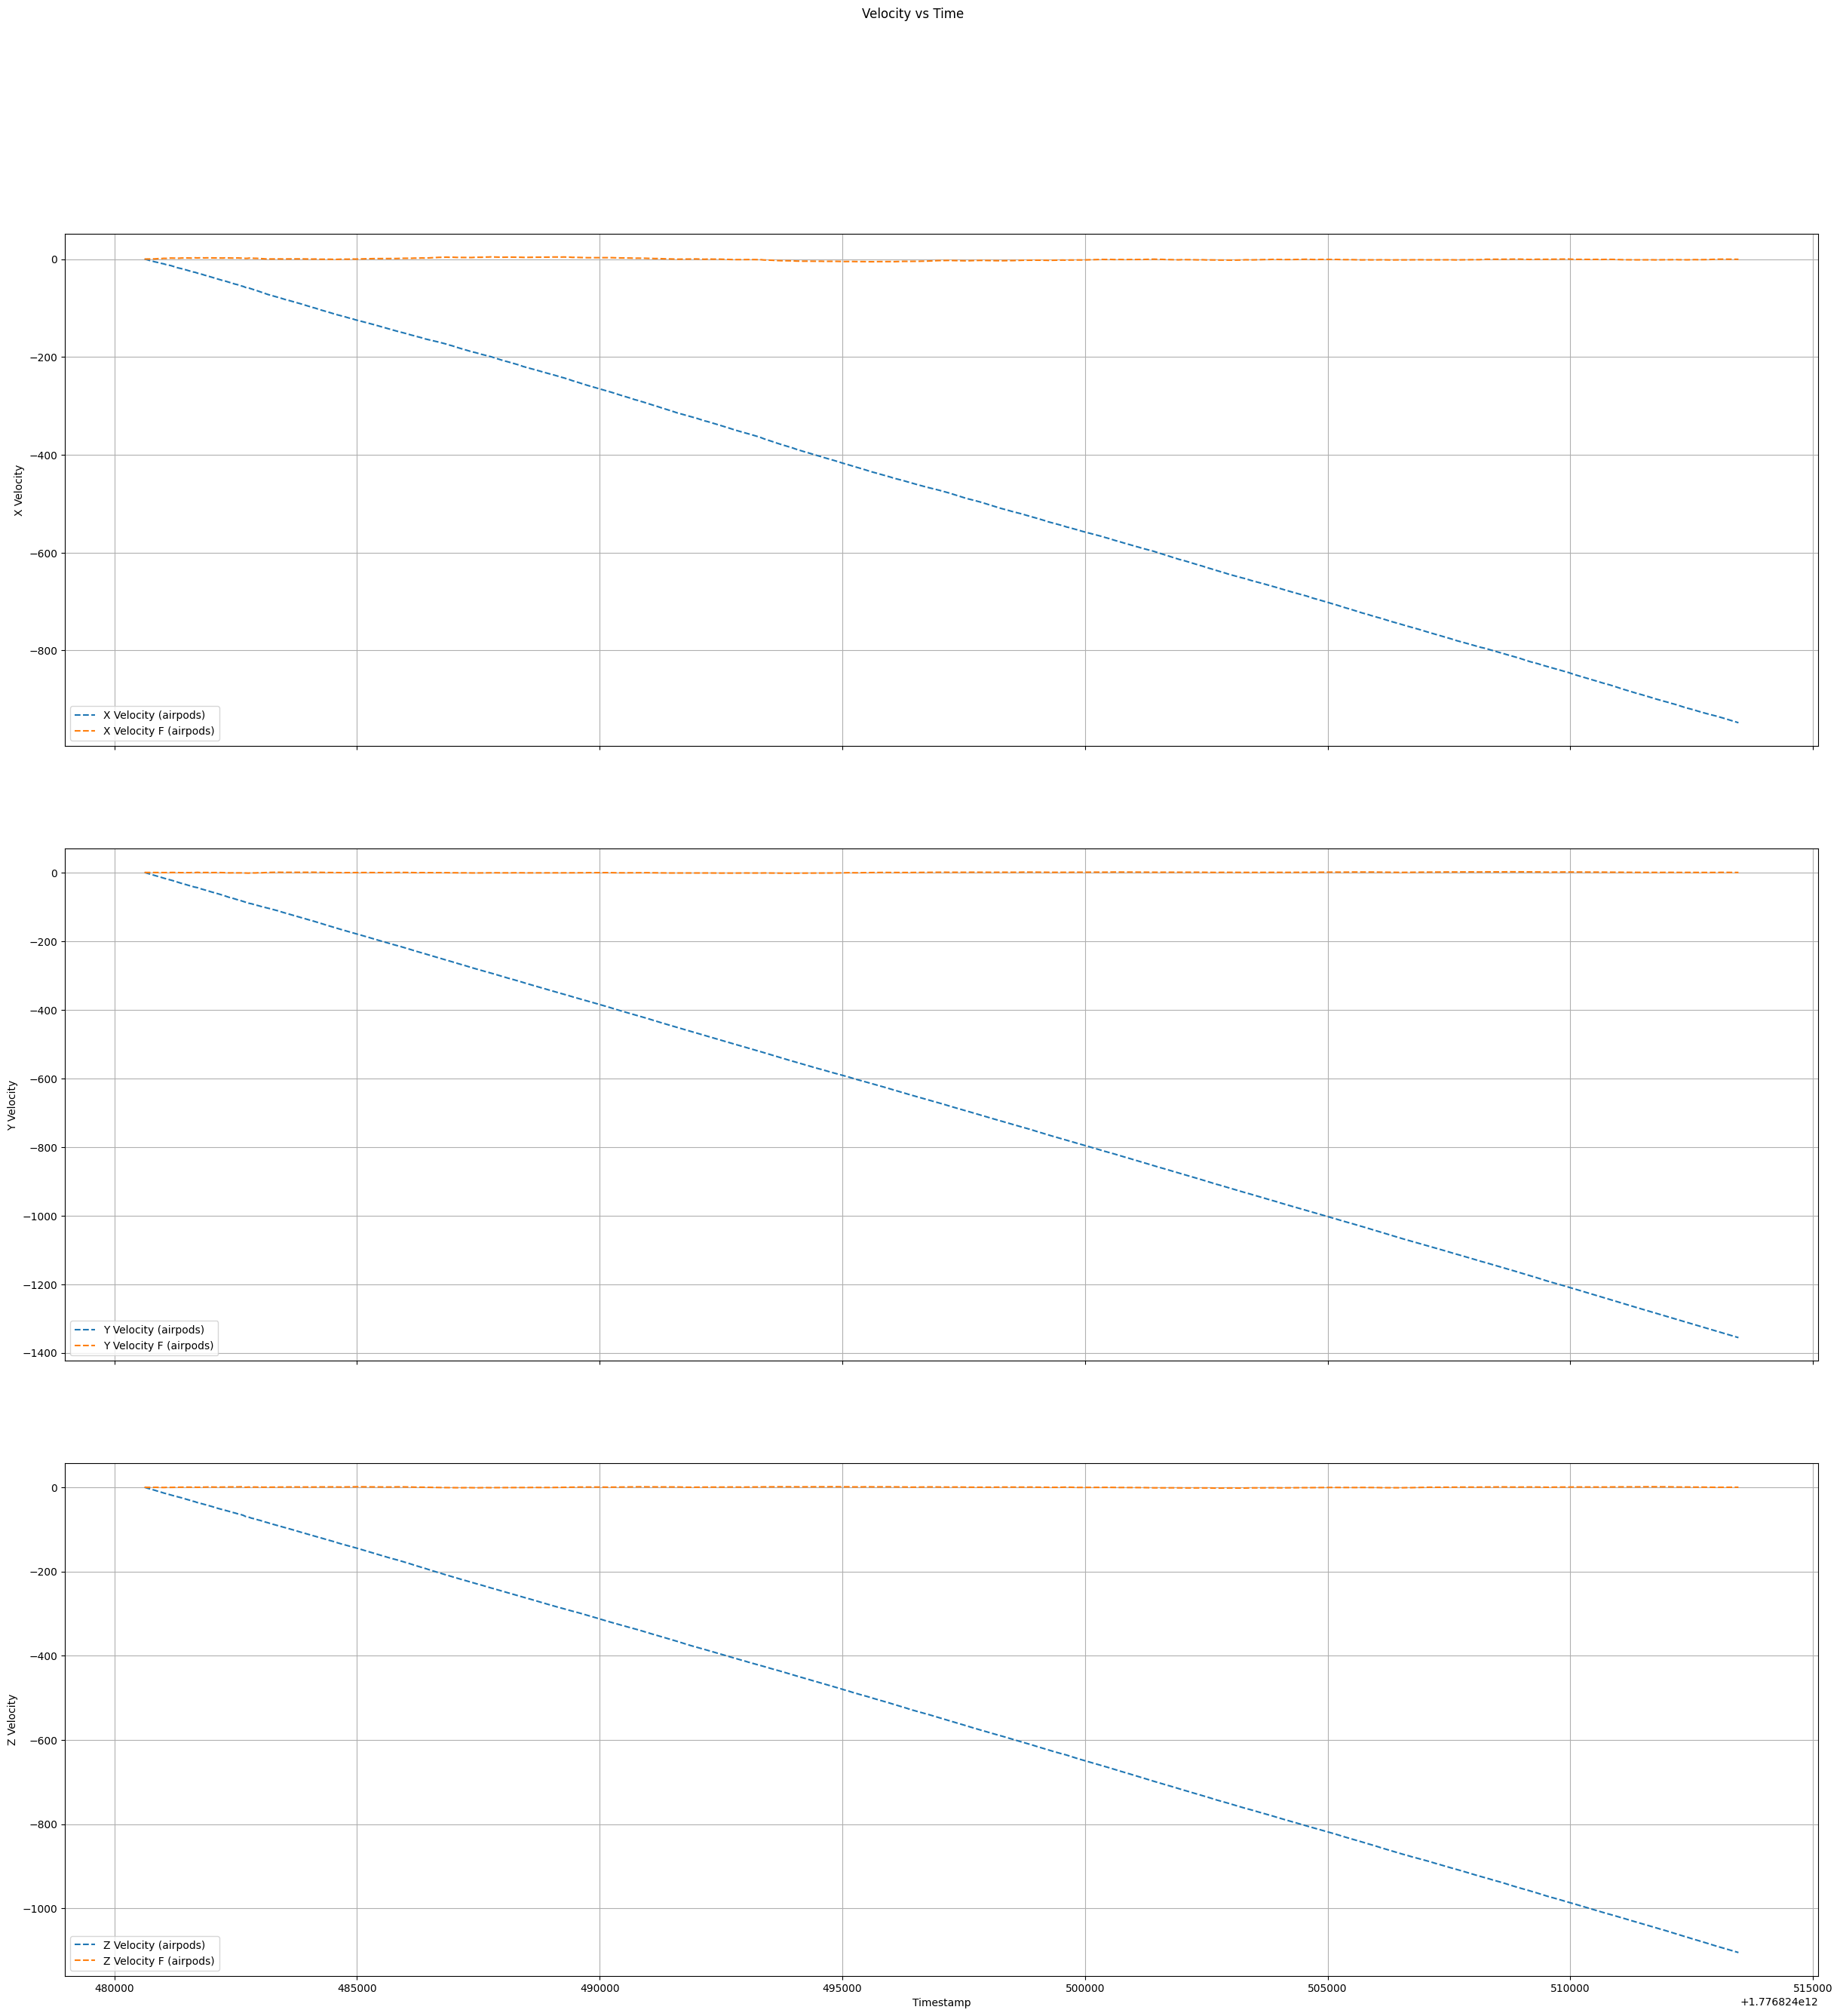

In [55]:
app_filename = "/Users/edwardzhou/Downloads/idle1.csv"
df_app = pd.read_csv(app_filename)
df_app = df_app.loc[df_app["source"] == "airpods"]
df_app = df_app.iloc[10:-10]

time_app = df_app["timestampEpoch"].values

def lowpass_filter(signal, time, cutoff, order=4):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist

    b, a = butter(order, normalized_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

def highpass_filter(signal, time, cutoff, order=2):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff / nyquist, btype='high', analog=False)
    return filtfilt(b, a, signal)
    
lp_cutoff_app = 10
hp_cutoff = 0.5

# convert Gs to m/s^2
ax_app = df_app["accel_x"].values * -9.81
ay_app = df_app["accel_y"].values * -9.81
az_app = df_app["accel_z"].values * -9.81
ax_app_f = detrend(ax_app, type='linear')
ay_app_f = detrend(ay_app, type='linear')
az_app_f = detrend(az_app, type='linear')
# ax_app_f = lowpass_filter(ax_app_f, time_app, lp_cutoff_app, 4)
# ay_app_f = lowpass_filter(ay_app_f, time_app, lp_cutoff_app, 4)
# az_app_f = lowpass_filter(az_app_f, time_app, lp_cutoff_app, 4)
# ax_app_f = highpass_filter(ax_app_f, time_app, hp_cutoff, 2)
# ay_app_f = highpass_filter(ay_app_f, time_app, hp_cutoff, 2)
# az_app_f = highpass_filter(az_app_f, time_app, hp_cutoff, 2)

vx_app = cumulative_trapezoid(ax_app, time_app, initial=0)
vy_app = cumulative_trapezoid(ay_app, time_app, initial=0)
vz_app = cumulative_trapezoid(az_app, time_app, initial=0)
v_app_mag = np.sqrt(vx_app**2 + vy_app**2 + vz_app**2)
v_app_rms = np.sqrt(np.mean(v_app_mag**2))

vx_app_f = cumulative_trapezoid(ax_app_f, time_app, initial=0)
vy_app_f = cumulative_trapezoid(ay_app_f, time_app, initial=0)
vz_app_f = cumulative_trapezoid(az_app_f, time_app, initial=0)
v_app_mag_f = np.sqrt(vx_app_f**2 + vy_app_f**2 + vz_app_f**2)
v_app_rms_f = np.sqrt(np.mean(v_app_mag_f**2))

fig, axes = plt.subplots(3, 1, figsize=(30, 30), sharex=True)

PLOT_VEL = True
if PLOT_VEL: 
    axes[0].plot(time_app, vx_app, linestyle="--", label="X Velocity (airpods)")
    axes[0].plot(time_app, vx_app_f, linestyle="--", label="X Velocity F (airpods)")
    axes[0].set_ylabel("X Velocity")
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(time_app, vy_app, linestyle="--", label="Y Velocity (airpods)")
    axes[1].plot(time_app, vy_app_f, linestyle="--", label="Y Velocity F (airpods)")
    axes[1].set_ylabel("Y Velocity")
    axes[1].legend()
    axes[1].grid(True)
    
    axes[2].plot(time_app, vz_app, linestyle="--", label="Z Velocity (airpods)")
    axes[2].plot(time_app, vz_app_f, linestyle="--", label="Z Velocity F (airpods)")
    axes[2].set_ylabel("Z Velocity")
    axes[2].set_xlabel("Timestamp")
    axes[2].legend()
    axes[2].grid(True)

    print("App RMSV: ", v_opti_rms_f)
else: 
    # axes[0].plot(time_app, ax_app, linestyle="--", label="X Acceleration (airpods)")
    # axes[0].plot(time_app, ax_app_f, linestyle="--", label="X Acceleration F (airpods)")
    axes[0].set_ylabel("X Acceleration")
    axes[0].legend()
    axes[0].grid(True)
    
    # axes[1].plot(time_app, ay_app, linestyle="--", label="Y Acceleration (airpods)")
    # axes[1].plot(time_app, ay_app_f, linestyle="--", label="Y Acceleration F (airpods)")
    axes[1].set_ylabel("Y Acceleration")
    axes[1].legend()
    axes[1].grid(True)
    
    # axes[2].plot(time_app, az_app, linestyle="--", label="Z Acceleration (airpods)")
    # axes[2].plot(time_app, az_app_f, linestyle="--", label="Z Acceleration F (airpods)")
    axes[2].set_ylabel("Z Acceleration")
    axes[2].set_xlabel("Timestamp")
    axes[2].legend()
    axes[2].grid(True)

plt.suptitle("Velocity vs Time")
plt.show()


App RMSV:  0.6500797569963065
Opti RMSV:  0.5117935047257057


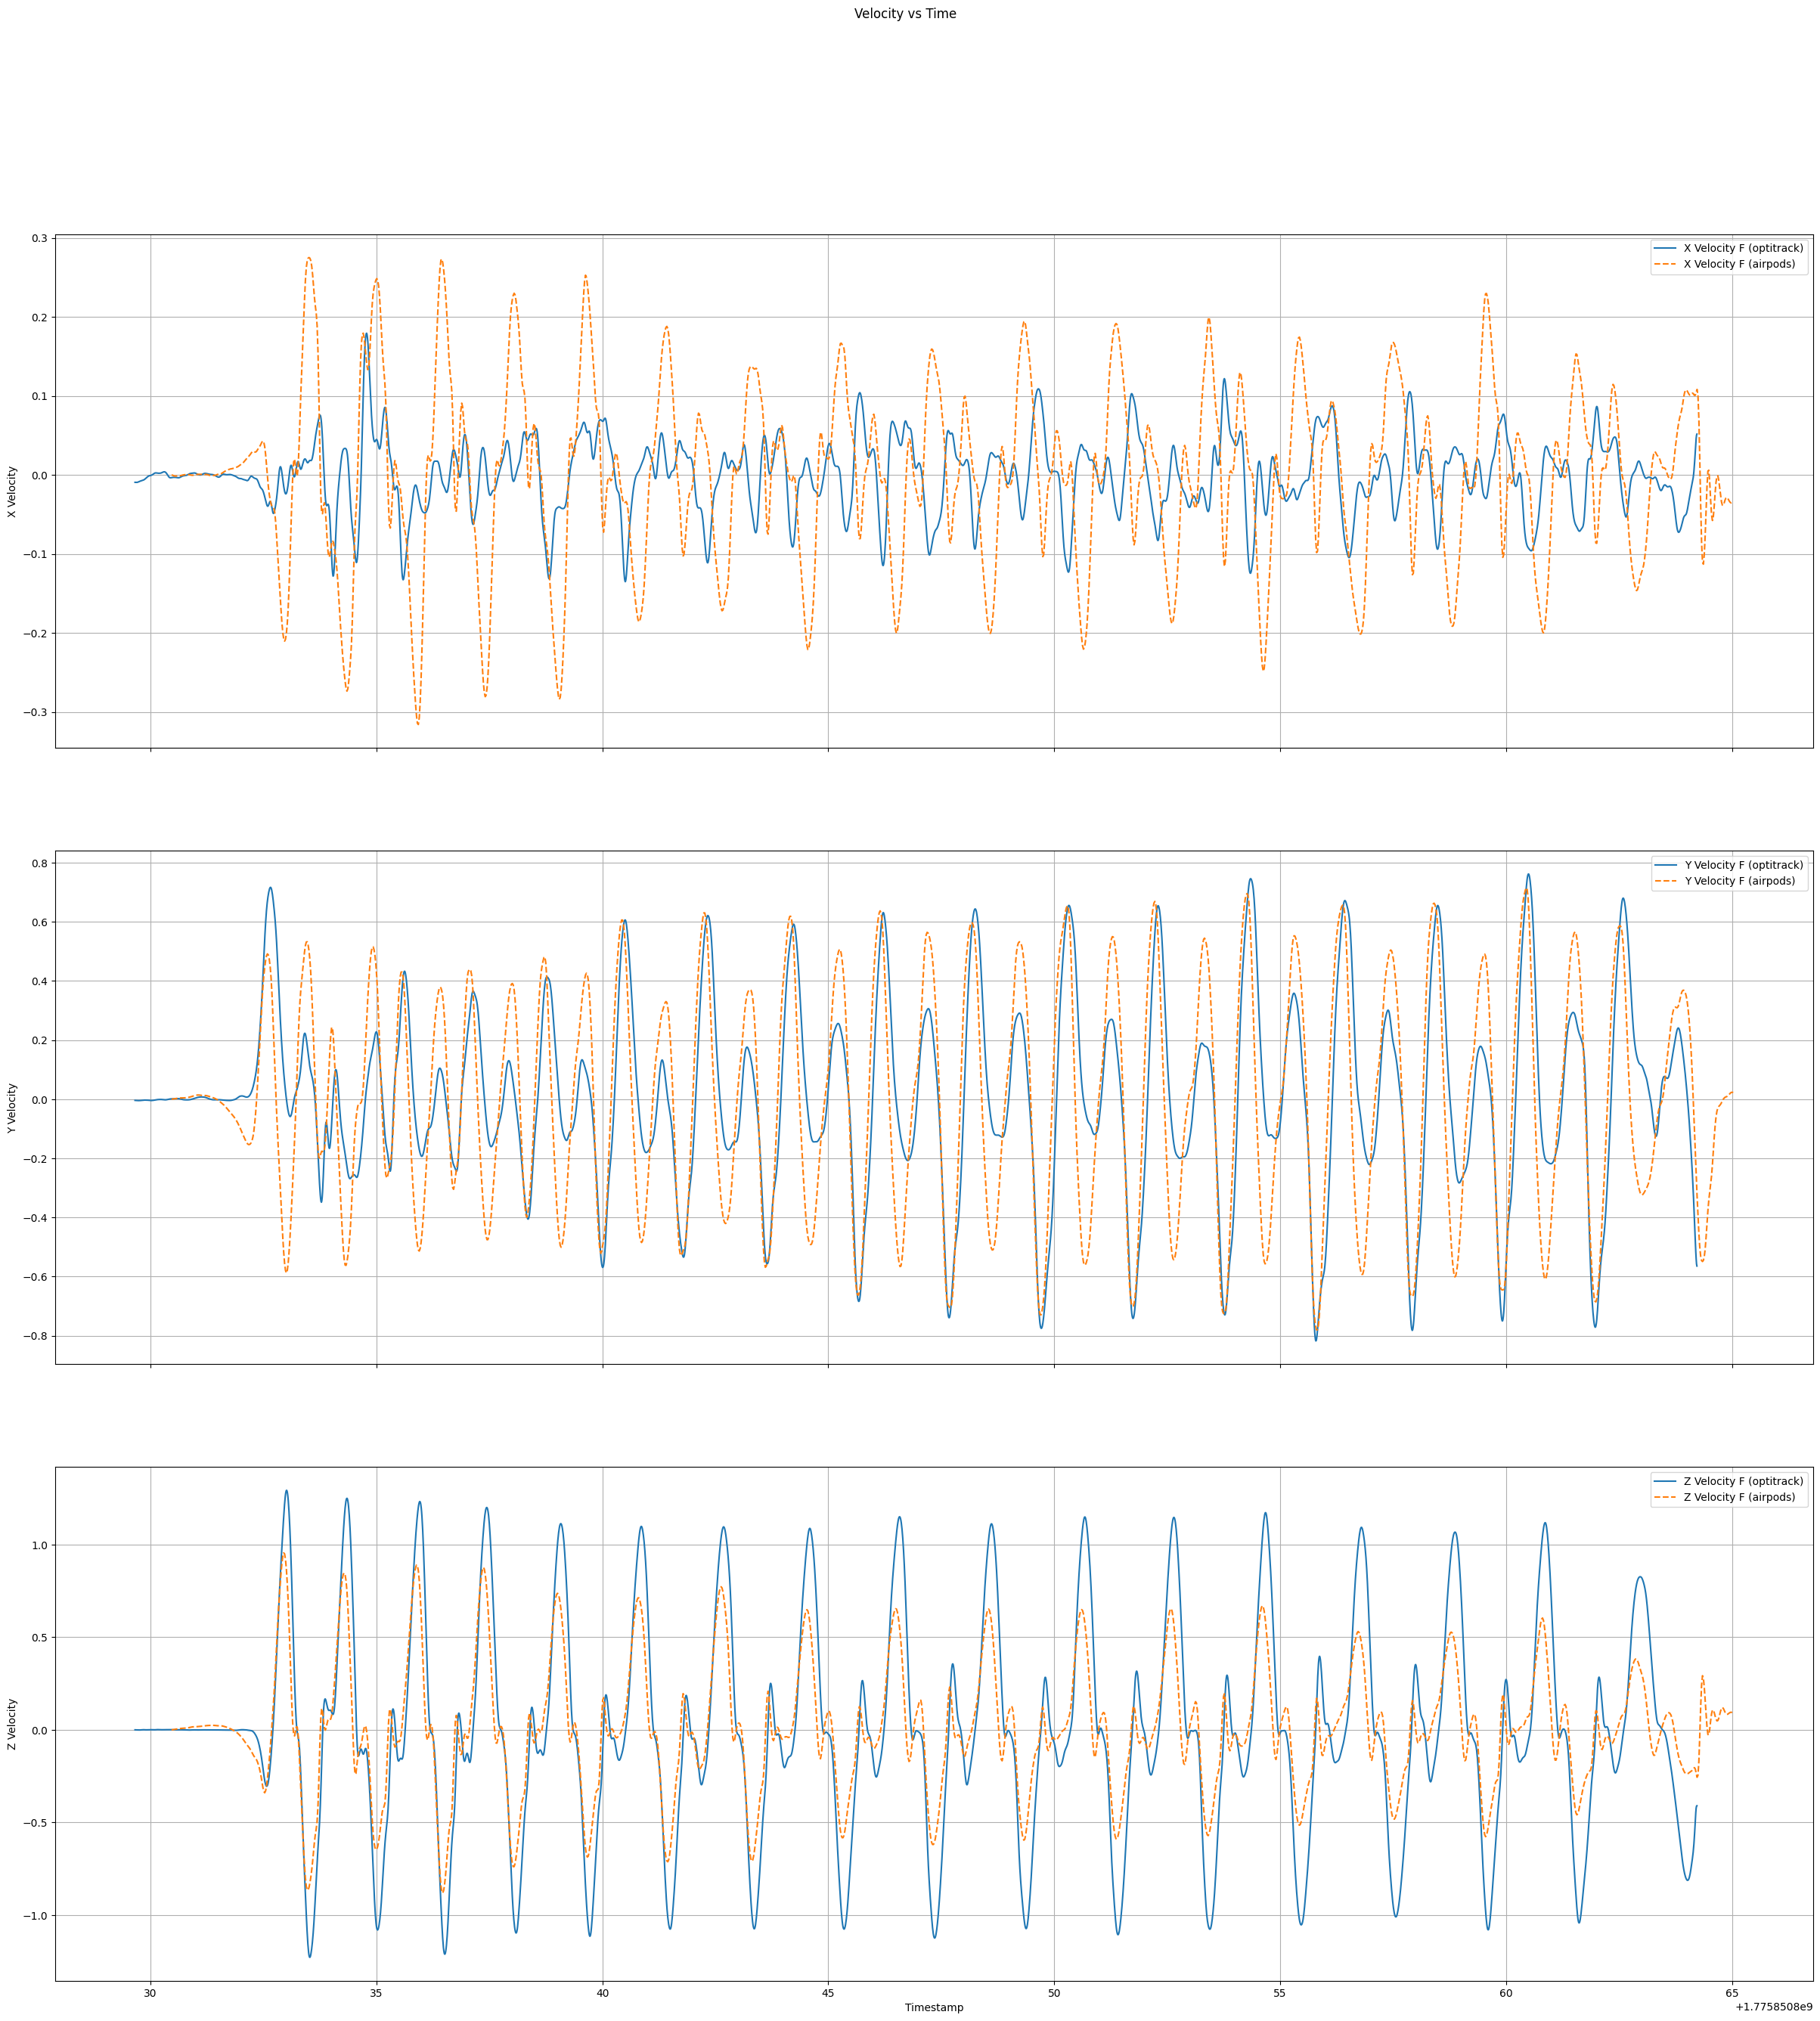

In [140]:
POSITIONS = [
    'sit',
    'stand',
    'standtandem',
    'standsingle',
    'sts'
]

VARIATIONS = [
    '',
    'eyesclosed',
    'foam',
    'foameyesclosed'
]

position = 4
variation = 0

TEST = f'{POSITIONS[position]}{VARIATIONS[variation]}'
PLOT_VEL = True

opti_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/optitrack/410{TEST}_opti.csv"

with open(opti_filename, 'r') as f:
    metadata = next(f)
    metadata_list = metadata.split(',')
    metadata_dict = {metadata_list[i]: metadata_list[i+1] for i in range(0, len(metadata_list), 2)}

    df_opti = pd.read_csv(f, skiprows=4, header=[0, 1])
    

start_time = datetime.strptime(metadata_dict['Capture Start Time'], "%Y-%m-%d %I.%M.%S.%f %p")

df_opti = df_opti.iloc[:, :8]
df_opti.columns = ["_".join([i.lower() for i in col if "Unnamed" not in i]) for col in df_opti.columns.values]
df_opti['timestampEpoch'] = df_opti['time (seconds)'] + start_time.timestamp()
df_opti['timestampEpoch'] *= 1000

app_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/airpods/410{TEST}.csv"
df_app = pd.read_csv(app_filename)
df_app = df_app.loc[df_app["source"] == "airpods"]
df_app = df_app.iloc[1:]

time_opti = df_opti["timestampEpoch"].values
time_app = df_app["timestampEpoch"].values

# Mask to get overlapping time only
time_start = max(time_opti[0], time_app[0])
time_end = min(time_opti[-1], time_app[-1])
mask_opti = (time_opti >= time_start) & (time_opti <= time_end)
mask_app = (time_app >= time_start) & (time_app <= time_end)

time_opti = time_opti[mask_opti] / 1000 - 0.8 # convert to seconds
df_opti = df_opti[mask_opti]
time_app = time_app[mask_app] / 1000 # convert to seconds
df_app = df_app[mask_app]

def lowpass_filter(signal, time, cutoff, order=4):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist

    b, a = butter(order, normalized_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

def highpass_filter(signal, time, cutoff, order=2):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff / nyquist, btype='high', analog=False)
    return filtfilt(b, a, signal)
    
lp_cutoff_opti = 10
lp_cutoff_app = 10
hp_cutoff = 0.5

px_opti = df_opti["position_x"].values / 1000
py_opti = df_opti["position_y"].values / 1000
pz_opti = df_opti["position_z"].values / 1000
px_opti_f = lowpass_filter(px_opti, time_opti, lp_cutoff_opti, 4)
py_opti_f = lowpass_filter(py_opti, time_opti, lp_cutoff_opti, 4)
pz_opti_f = lowpass_filter(pz_opti, time_opti, lp_cutoff_opti, 4)

vx_opti = np.gradient(px_opti, time_opti)
vy_opti = np.gradient(py_opti, time_opti)
vz_opti = np.gradient(pz_opti, time_opti)
v_opti_mag = np.sqrt(vx_opti**2 + vy_opti**2 + vz_opti**2)
v_opti_rms = np.sqrt(np.mean(v_opti_mag**2))

vx_opti_f = np.gradient(px_opti_f, time_opti)
vy_opti_f = np.gradient(py_opti_f, time_opti)
vz_opti_f = np.gradient(pz_opti_f, time_opti)
v_opti_mag_f = np.sqrt(vx_opti_f**2 + vy_opti_f**2 + vz_opti_f**2)
v_opti_rms_f = np.sqrt(np.mean(v_opti_mag_f**2))

ax_opti = np.gradient(vx_opti, time_opti)
ay_opti = np.gradient(vy_opti, time_opti)
az_opti = np.gradient(vz_opti, time_opti)
ax_opti_f = np.gradient(vx_opti_f, time_opti)
ay_opti_f = np.gradient(vy_opti_f, time_opti)
az_opti_f = np.gradient(vz_opti_f, time_opti)

# convert Gs to m/s^2
ax_app = df_app["accel_x"].values * -9.81
ay_app = df_app["accel_y"].values * -9.81
az_app = df_app["accel_z"].values * -9.81
ax_app_f = detrend(ax_app, type='linear')
ay_app_f = detrend(ay_app, type='linear')
az_app_f = detrend(az_app, type='linear')
ax_app_f = lowpass_filter(ax_app_f, time_app, lp_cutoff_app, 4)
ay_app_f = lowpass_filter(ay_app_f, time_app, lp_cutoff_app, 4)
az_app_f = lowpass_filter(az_app_f, time_app, lp_cutoff_app, 4)
ax_app_f = highpass_filter(ax_app_f, time_app, hp_cutoff, 2)
ay_app_f = highpass_filter(ay_app_f, time_app, hp_cutoff, 2)
az_app_f = highpass_filter(az_app_f, time_app, hp_cutoff, 2)

vx_app = cumulative_trapezoid(ax_app, time_app, initial=0)
vy_app = cumulative_trapezoid(ay_app, time_app, initial=0)
vz_app = cumulative_trapezoid(az_app, time_app, initial=0)
v_app_mag = np.sqrt(vx_app**2 + vy_app**2 + vz_app**2)
v_app_rms = np.sqrt(np.mean(v_app_mag**2))

vx_app_f = cumulative_trapezoid(ax_app_f, time_app, initial=0)
vy_app_f = cumulative_trapezoid(ay_app_f, time_app, initial=0)
vz_app_f = cumulative_trapezoid(az_app_f, time_app, initial=0)
v_app_mag_f = np.sqrt(vx_app_f**2 + vy_app_f**2 + vz_app_f**2)
v_app_rms_f = np.sqrt(np.mean(v_app_mag_f**2))

fig, axes = plt.subplots(3, 1, figsize=(30, 30), sharex=True)

if PLOT_VEL: 
    # axes[0].plot(time_opti, vx_opti, label="X Velocity (optitrack)")
    axes[0].plot(time_opti, vx_opti_f, label="X Velocity F (optitrack)")
    # axes[0].plot(time_app, vx_app, linestyle="--", label="X Velocity (airpods)")
    axes[0].plot(time_app, vx_app_f, linestyle="--", label="X Velocity F (airpods)")
    axes[0].set_ylabel("X Velocity")
    axes[0].legend()
    axes[0].grid(True)
    
    # axes[1].plot(time_opti, vy_opti, label="Y Velocity (optitrack)")
    axes[1].plot(time_opti, vy_opti_f, label="Y Velocity F (optitrack)")
    # axes[1].plot(time_app, vy_app, linestyle="--", label="Y Velocity (airpods)")
    axes[1].plot(time_app, vy_app_f, linestyle="--", label="Y Velocity F (airpods)")
    axes[1].set_ylabel("Y Velocity")
    axes[1].legend()
    axes[1].grid(True)
    
    # axes[2].plot(time_opti, vz_opti, label="Z Velocity (optitrack)")
    axes[2].plot(time_opti, vz_opti_f, label="Z Velocity F (optitrack)")
    # axes[2].plot(time_app, vz_app, linestyle="--", label="Z Velocity (airpods)")
    axes[2].plot(time_app, vz_app_f, linestyle="--", label="Z Velocity F (airpods)")
    axes[2].set_ylabel("Z Velocity")
    axes[2].set_xlabel("Timestamp")
    axes[2].legend()
    axes[2].grid(True)

    print("App RMSV: ", v_opti_rms_f)
    print("Opti RMSV: ", v_app_rms_f)
else: 
    # axes[0].plot(time_opti, ax_opti, label="X Acceleration (optitrack)")
    axes[0].plot(time_opti, ax_opti_f, label="X Acceleration F (optitrack)")
    # axes[0].plot(time_app, ax_app, linestyle="--", label="X Acceleration (airpods)")
    axes[0].plot(time_app, ax_app_f, linestyle="--", label="X Acceleration F (airpods)")
    axes[0].set_ylabel("X Acceleration")
    axes[0].legend()
    axes[0].grid(True)
    
    # axes[1].plot(time_opti, ay_opti, label="Y Acceleration (optitrack)")
    axes[1].plot(time_opti, ay_opti_f, label="Y Acceleration F (optitrack)")
    # axes[1].plot(time_app, ay_app, linestyle="--", label="Y Acceleration (airpods)")
    axes[1].plot(time_app, ay_app_f, linestyle="--", label="Y Acceleration F (airpods)")
    axes[1].set_ylabel("Y Acceleration")
    axes[1].legend()
    axes[1].grid(True)
    
    # axes[2].plot(time_opti, az_opti, label="Z Acceleration (optitrack)")
    axes[2].plot(time_opti, az_opti_f, label="Z Acceleration F (optitrack)")
    # axes[2].plot(time_app, az_app, linestyle="--", label="Z Acceleration (airpods)")
    axes[2].plot(time_app, az_app_f, linestyle="--", label="Z Acceleration F (airpods)")
    axes[2].set_ylabel("Z Acceleration")
    axes[2].set_xlabel("Timestamp")
    axes[2].legend()
    axes[2].grid(True)

plt.suptitle("Velocity vs Time")
plt.show()


In [194]:
POSITIONS = ['sit', 'stand', 'standtandem', 'standsingle', 'sts']
VARIATIONS = ['', 'eyesclosed', 'foam', 'foameyesclosed']

V_AXES = ['vx','vy','vz']
A_AXES = ['ax','ay','az']

lp_cutoff = 10
hp_cutoff = 0.25

BASE_PATH = "/Users/edwardzhou/Desktop/FRL/BalanceProject/data/5-8"

def lowpass(signal, time, cutoff, order=4):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    b, a = butter(order, cutoff / (0.5 * fs), btype='low')
    return filtfilt(b, a, signal)

def highpass(signal, time, cutoff, order=2):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    b, a = butter(order, cutoff / (0.5 * fs), btype='high')
    return filtfilt(b, a, signal)

def load_opti(test_name):
    filename = f"{BASE_PATH}/optitrack/{test_name}.csv"
    
    with open(filename, 'r') as f:
        metadata = next(f)
        meta = metadata.split(',')
        meta_dict = {meta[i]: meta[i+1] for i in range(0, len(meta), 2)}
        df = pd.read_csv(f, skiprows=4, header=[0, 1])

    start_time = datetime.strptime(
        meta_dict['Capture Start Time'],
        "%Y-%m-%d %I.%M.%S.%f %p"
    )

    df = df.iloc[:, :8]
    df.columns = ["_".join([i.lower() for i in col if "Unnamed" not in i]) for col in df.columns]

    df['timestamp'] = (df['time (seconds)'] + start_time.timestamp()) * 1000
    return df

def load_app(test_name):
    filename = f"{BASE_PATH}/airpods/{test_name}.csv"
    df = pd.read_csv(filename)
    df = df[df["source"] == "airpods"].iloc[1:]
    return df

# ---------------------- PROCESS ----------------------
def process_trial(opti, app):
    
    df_opti = load_opti(opti)
    df_app = load_app(app)

    # Align time
    t_opti = df_opti["timestamp"].values
    t_app = df_app["timestampEpoch"].values

    t_start = max(t_opti[0], t_app[0])
    t_end = min(t_opti[-1], t_app[-1])

    mask_o = (t_opti >= t_start) & (t_opti <= t_end)
    mask_a = (t_app >= t_start) & (t_app <= t_end)

    t_opti = t_opti[mask_o] / 1000
    t_app = t_app[mask_a] / 1000

    t_opti -= t_start
    t_app -= t_start

    df_opti = df_opti[mask_o]
    df_app = df_app[mask_a]


    px_opti = df_opti["position_x"].values / 1000
    py_opti = df_opti["position_y"].values / 1000
    pz_opti = df_opti["position_z"].values / 1000

    px_opti_f = lowpass(px_opti, t_opti, lp_cutoff)
    py_opti_f = lowpass(py_opti, t_opti, lp_cutoff)
    pz_opti_f = lowpass(pz_opti, t_opti, lp_cutoff)

    vx_opti = np.gradient(px_opti_f, t_opti)
    vy_opti = np.gradient(py_opti_f, t_opti)
    vz_opti = np.gradient(pz_opti_f, t_opti)
    
    ax_opti = np.gradient(vx_opti, t_opti)
    ay_opti = np.gradient(vy_opti, t_opti)
    az_opti = np.gradient(vz_opti, t_opti)

    ax_app = df_app["accel_x"].values * -9.81
    ay_app = df_app["accel_y"].values * -9.81
    az_app = df_app["accel_z"].values * -9.81

    ax_app = highpass(lowpass((ax_app), t_app, lp_cutoff), t_app, hp_cutoff)
    ay_app = highpass(lowpass((ay_app), t_app, lp_cutoff), t_app, hp_cutoff)
    az_app = highpass(lowpass((az_app), t_app, lp_cutoff), t_app, hp_cutoff)

    vx_app = cumulative_trapezoid(ax_app, t_app, initial=0)
    vy_app = cumulative_trapezoid(ay_app, t_app, initial=0)
    vz_app = cumulative_trapezoid(az_app, t_app, initial=0)

    return {
        "opti": {
            "time": t_opti,
            "vx": vx_opti,
            "vy": vy_opti,
            "vz": vz_opti,
            "ax": ax_opti,
            "ay": ay_opti,
            "az": az_opti,
        },
        "app": {
            "time": t_app,
            "vx": vx_app,
            "vy": vy_app,
            "vz": vz_app,
            "ax": ax_app,
            "ay": ay_app,
            "az": az_app,
        },
        "label": opti
    }

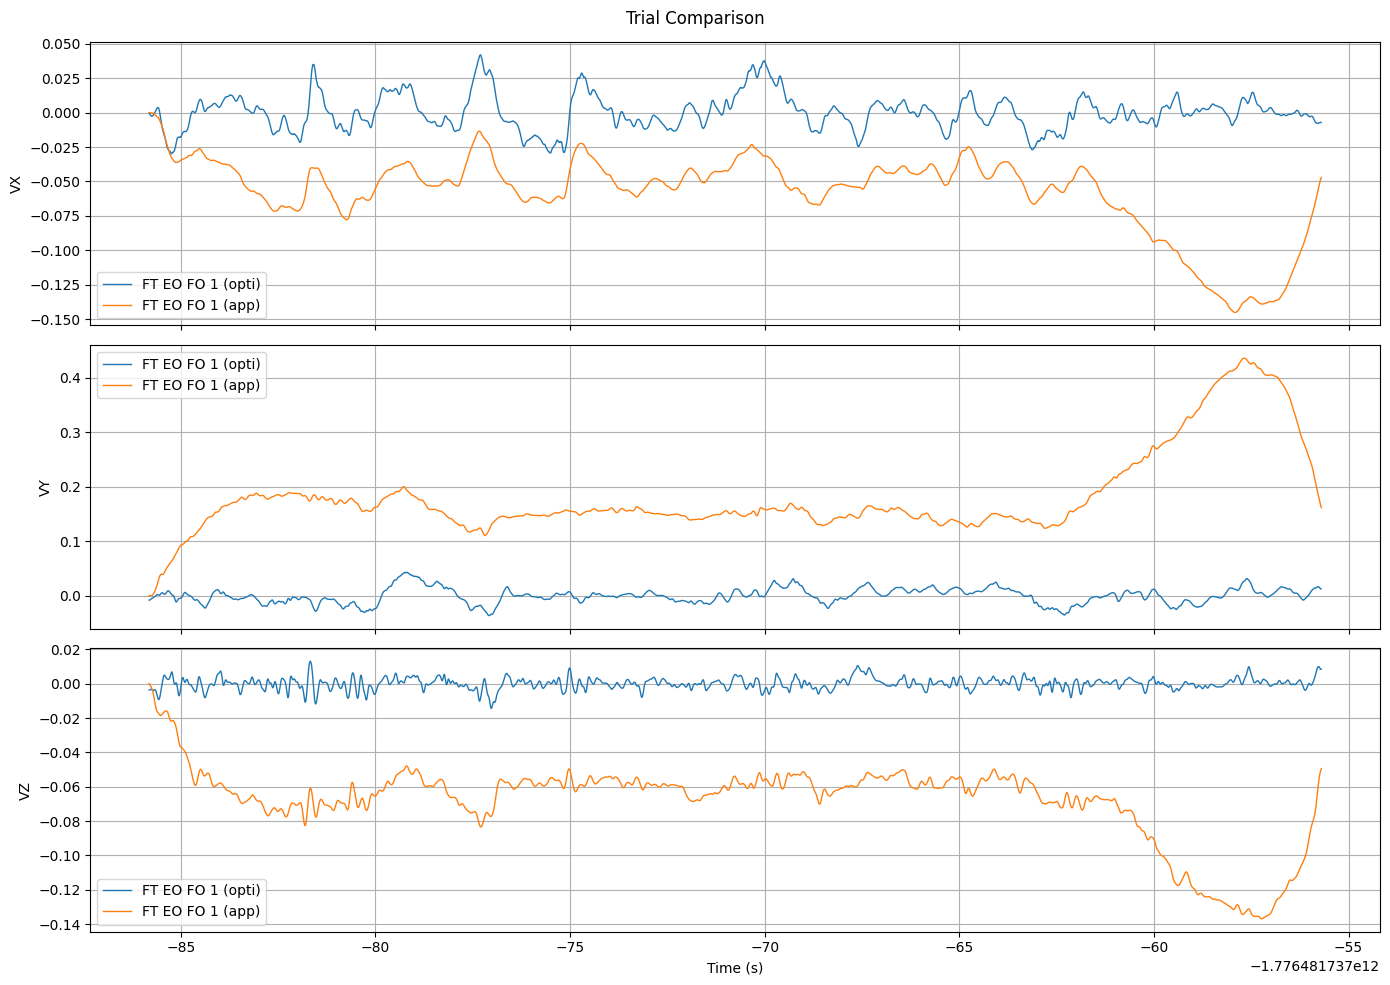

In [195]:
trial_1_opti = "FT EO FO 1"
trial_1_app = "FT-EO-FO-1"

trial_2_opti = "STS 1"
trial_2_app = "STS-1"

plot_data = V_AXES
plot_source = "opti"


trial1 = process_trial(trial_1_opti, trial_1_app)
trial2 = process_trial(trial_2_opti, trial_2_app)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)


for i, axis in enumerate(plot_data):
    axes[i].plot(trial1["opti"]["time"], trial1["opti"][axis],
                 label=f'{trial1["label"]} ({"opti"})', linewidth=1)
    # axes[i].plot(trial2["opti"]["time"], trial2["opti"][axis],
    #              label=f'{trial2["label"]} ({"opti"})', linewidth=1)

    axes[i].plot(trial1["app"]["time"], trial1["app"][axis],
                 label=f'{trial1["label"]} ({"app"})', linewidth=1)
    # axes[i].plot(trial2["app"]["time"], trial2["app"][axis],
    #              label=f'{trial2["label"]} ({"app"})', linewidth=1)

    axes[i].set_ylabel(axis.upper())
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("Time (s)")
plt.suptitle("Trial Comparison")
plt.tight_layout()
plt.show()